In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_full
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
setup_logging()
log = get_logger(__name__)

df = load_missions_full()

01:23:33  INFO      load_missions_full → 7,007 rows


In [3]:


plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.7,
    "font.size":         11,
})

In [4]:
print(f"Total missions:      {len(df):,}")
print(f"Unique agencies:     {df['agency_name'].nunique()}")
print(f"Unique countries:    {df['country_region'].nunique()}")
print(f"Year range:          {df['launch_year'].min()} — {df['launch_year'].max()}")
print(f"Crewed missions:     {(df['crew_type']=='Crewed').sum():,}")
print(f"Uncrewed missions:   {(df['crew_type']=='Uncrewed').sum():,}")
print(f"\nStatus breakdown:")
print(df["status"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Total missions:      7,007
Unique agencies:     11
Unique countries:    9
Year range:          1958 — 2035
Crewed missions:     1,737
Uncrewed missions:   5,270

Status breakdown:
status
Ongoing            35.65%
Success             32.3%
Upcoming           20.52%
Failed              7.06%
Partial Success     4.47%
Name: proportion, dtype: object


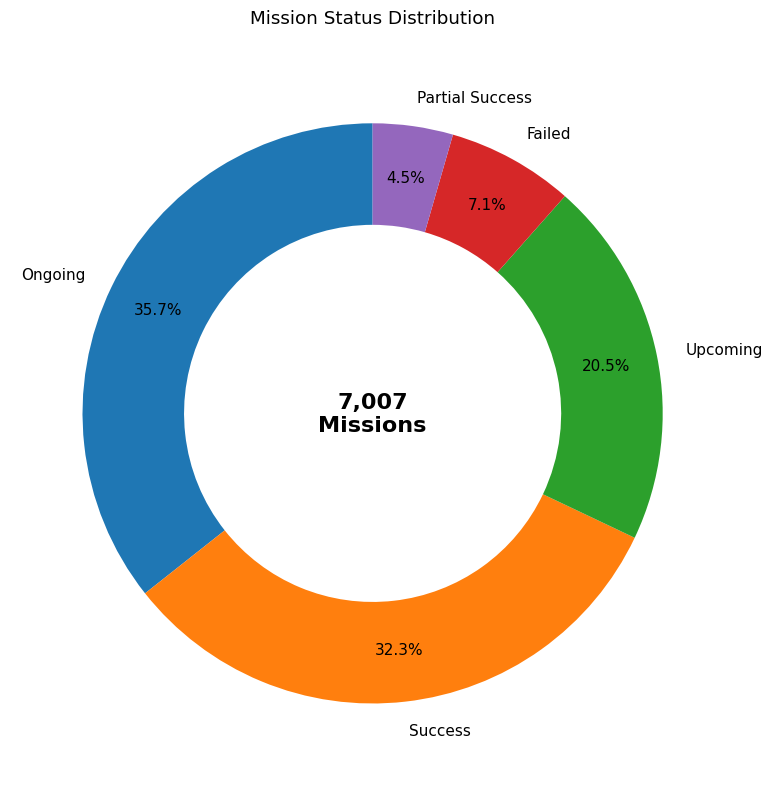

In [5]:
status_counts = df["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35)
)


ax.text(
    0, 0,
    f"{status_counts.sum():,}\nMissions",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title("Mission Status Distribution", pad=20)

plt.tight_layout()
plt.show()

In [6]:
agency_summary = df.groupby("agency_name").agg(
    total_missions=("mission_id", "count"),
    successful_missions=("status", lambda x: (x == "Success").sum()),
    failed_missions=("status", lambda x: (x == "Failed").sum()),
    upcoming_missions=("status", lambda x: (x == "Upcoming").sum()),
    ongoing_missions=("status", lambda x: (x == "Ongoing").sum()),
    partially_successful_missions=("status", lambda x: (x == "Partial Success").sum()),
    avg_cost_billion=("cost_usd_billion", lambda x: round(x.mean(), 2)),
    total_cost_billion=("cost_usd_billion", "sum"),
    avg_duration_days=("duration_days", lambda x: round(x.mean(), 2)),
    agency_type=("agency_type", lambda x: x.mode()[0] if not x.mode().empty else "Unknown"),
    crewed_missions=("crew_type", lambda x: (x == "Crewed").sum()),).reset_index()

agency_summary["success_rate"] = (agency_summary["successful_missions"] / agency_summary["total_missions"] * 100).round(2)



agency_summary = agency_summary[agency_summary["total_missions"] > 5]

agency_summary["cost_per_success"] = (
    pd.to_numeric(agency_summary["total_cost_billion"]) / agency_summary["successful_missions"]).round(2)

agency_summary["success_rate"] = agency_summary["success_rate"].apply(lambda x: f"{x:.2f}%")

agency_summary.reset_index(drop=True, inplace=True)
agency_summary

,agency_name,total_missions,successful_missions,failed_missions,upcoming_missions,ongoing_missions,partially_successful_missions,avg_cost_billion,total_cost_billion,avg_duration_days,agency_type,crewed_missions,success_rate,cost_per_success
0,ASI,573,172,39,116,216,30,7.51,4304.16,2162.55,Government,145,30.02%,25.02
1,Blue Origin,522,142,30,118,214,18,7.43,3876.76,2007.31,Private,141,27.20%,27.30
2,CNES,783,290,71,125,253,44,7.48,5860.33,2502.11,Government,197,37.04%,20.21
3,CNSA,606,180,26,152,226,22,7.19,4357.62,2221.33,Government,138,29.70%,24.21
4,CSA,532,157,33,125,196,21,7.42,3949.17,2312.61,Government,141,29.51%,25.15
5,DLR,522,137,33,133,199,20,7.55,3940.37,2018.84,Government,140,26.25%,28.76
6,ESA,743,262,59,143,254,25,7.56,5614.12,2417.37,Government,188,35.26%,21.43
7,ISRO,748,294,77,118,220,39,7.47,5584.77,2475.18,Government,191,39.30%,19.00
8,JAXA,475,108,16,142,194,15,7.00,3322.89,1678.88,Government,115,22.74%,30.77
9,NASA,960,387,85,135,294,59,7.18,6889.08,2590.67,Government,216,40.31%,17.80


In [7]:
# One colour per agency 
PALETTE = [
    "#378ADD","#E24B4A","#1D9E75","#EF9F27","#534AB7",
    "#D4537E","#639922","#BA7517","#D85A30","#888780","#5DCAA5","#7A5AF8"
]
color_map = dict(zip(agency_summary["agency_name"], PALETTE))


In [8]:
agency_summary.sort_values("total_missions", ascending=False,inplace=True)

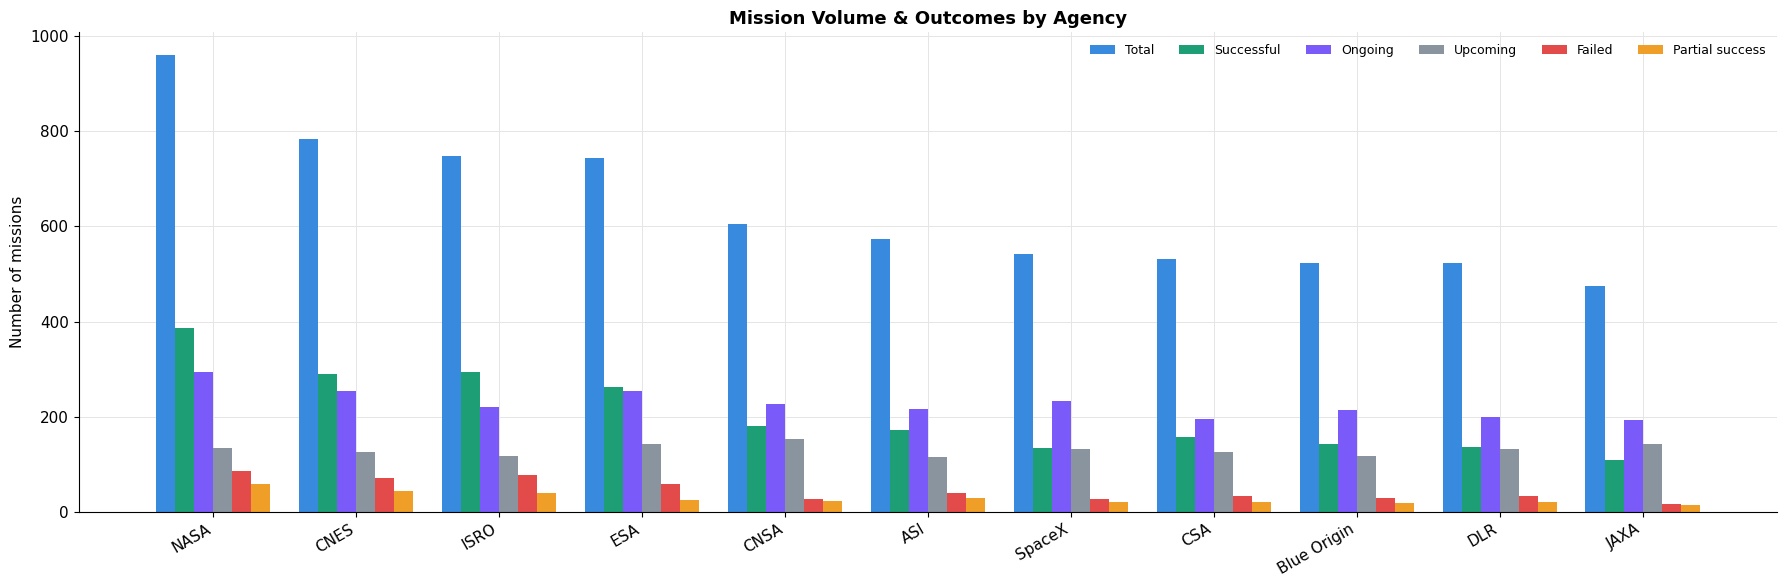

In [9]:
groups = [
    ("total_missions",                "Total",           "#378ADD"),
    ("successful_missions",           "Successful",      "#1D9E75"),
    ("ongoing_missions",              "Ongoing",         "#7A5AF8"),
    ("upcoming_missions",             "Upcoming",        "#8A949E"),
    ("failed_missions",               "Failed",          "#E24B4A"),
    ("partially_successful_missions", "Partial success", "#EF9F27"),
]

#these are derived values, not hardcoded, so the code is more robust to changes in the groups list
n_groups   = len(groups)                          
n_agencies = len(agency_summary)                  

# width of each bar within a cluster, derived from total cluster width and number of bars
cluster_width = 0.80
w = cluster_width / n_groups                      


fig, ax = plt.subplots(figsize=(max(18, n_agencies * 1.4), 6))

#x positions for each agency cluster
x = np.arange(n_agencies)

for i, (col, label, colour) in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * w
    ax.bar(x + offset, agency_summary[col],
           width=w, label=label, color=colour, edgecolor="none")

ax.set_title("Mission Volume & Outcomes by Agency", fontsize=13, fontweight="bold")
ax.set_xticks(x)
#changing the labels back to the agency names, rotated for readability
ax.set_xticklabels(agency_summary["agency_name"], rotation=30, ha="right")
ax.set_ylabel("Number of missions")
ax.legend(frameon=False, ncol=6, loc="upper right", fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

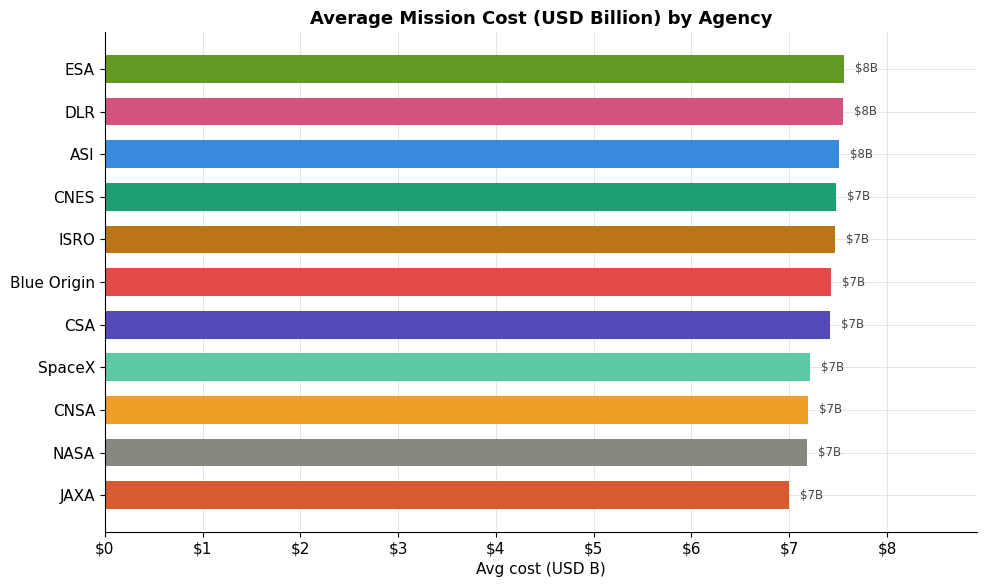

In [9]:
df_cost = agency_summary.sort_values("avg_cost_billion")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_cost["agency_name"],
    df_cost["avg_cost_billion"],
    color=[color_map[a] for a in df_cost["agency_name"]],
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_cost["avg_cost_billion"]):
    ax.text(
        val + (df_cost["avg_cost_billion"].max() * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}B",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Average Mission Cost (USD Billion) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Avg cost (USD B)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.set_xlim(0, df_cost["avg_cost_billion"].max() * 1.18)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

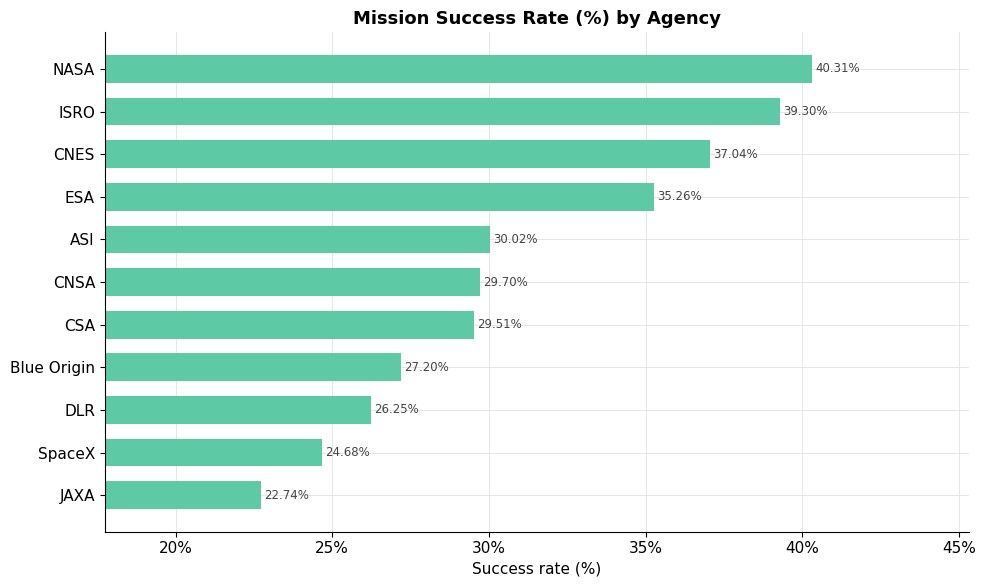

In [10]:

df_sr = agency_summary.copy()
df_sr["success_rate_num"] = df_sr["success_rate"].str.replace("%", "").astype(float)
df_sr = df_sr.sort_values("success_rate_num")


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_sr["agency_name"],
    df_sr["success_rate_num"],
    color="#5DCAA5",
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_sr["success_rate_num"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Mission Success Rate (%) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (%)")
ax.set_xlim(
    df_sr["success_rate_num"].min() - 5,
    df_sr["success_rate_num"].max() + 5,
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

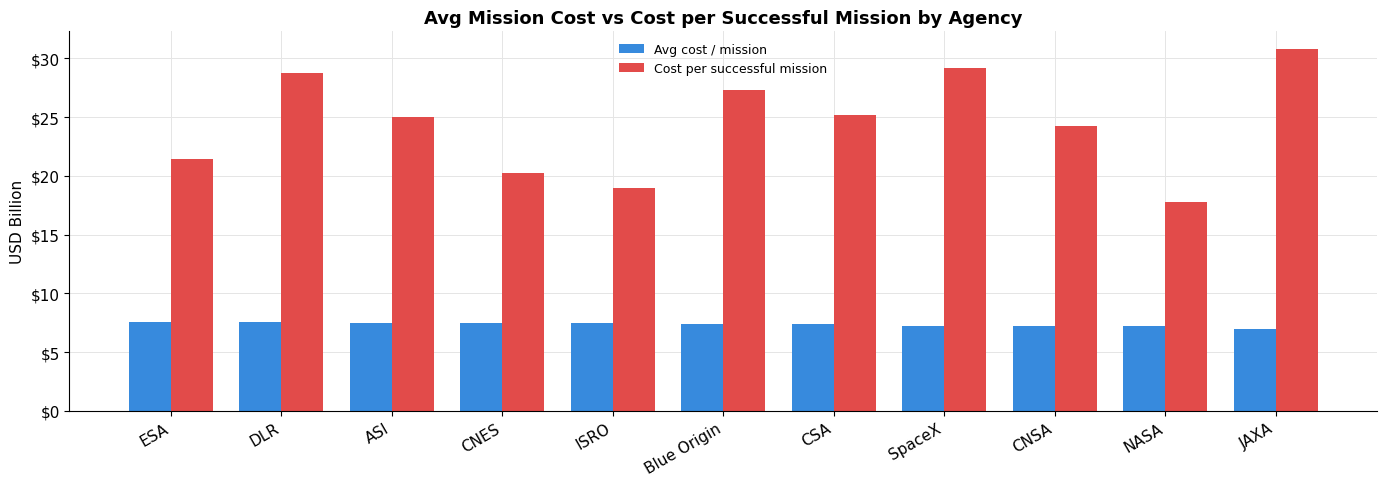

In [11]:
df_bp = agency_summary[["agency_name", "avg_cost_billion", "cost_per_success"]].copy()
df_bp = df_bp.sort_values("avg_cost_billion", ascending=False)

x = np.arange(len(df_bp))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w / 2, df_bp["avg_cost_billion"],
       width=w, color="#378ADD", edgecolor="none", label="Avg cost / mission")
ax.bar(x + w / 2, df_bp["cost_per_success"],
       width=w, color="#E24B4A", edgecolor="none", label="Cost per successful mission")

ax.set_title("Avg Mission Cost vs Cost per Successful Mission by Agency",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_bp["agency_name"], rotation=30, ha="right")
ax.set_ylabel("USD Billion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.legend(frameon=False, fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

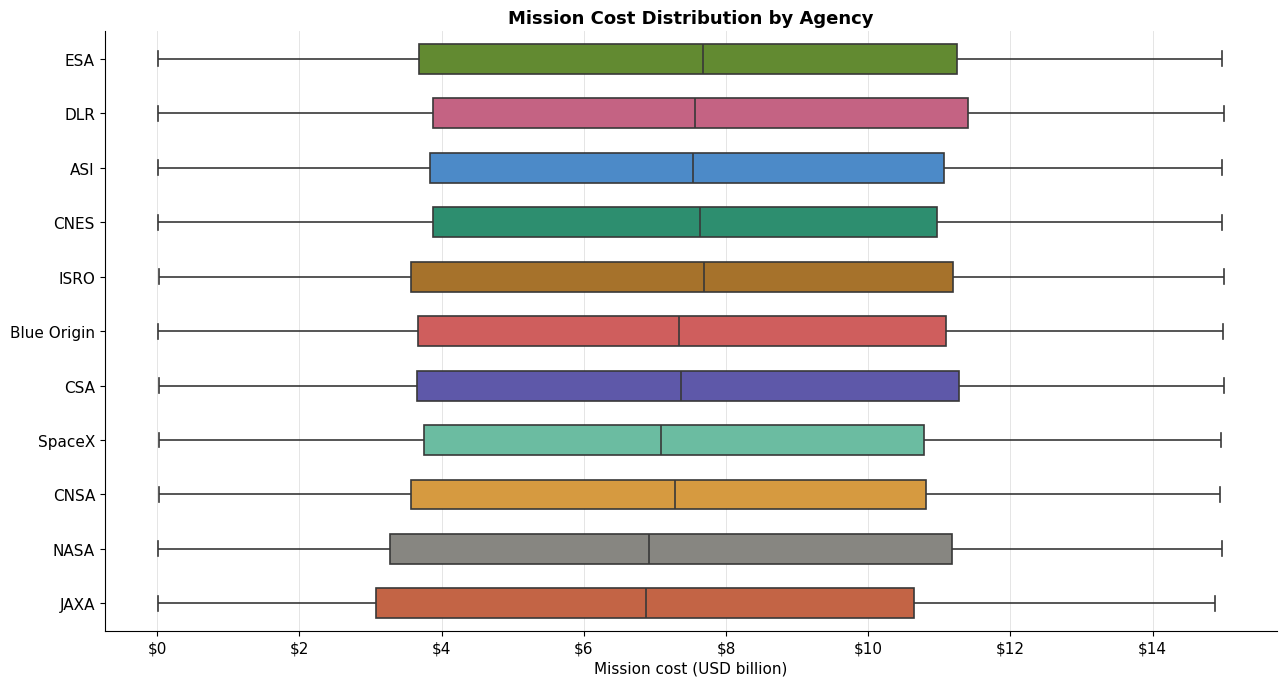

In [12]:
order = (
    agency_summary
    .sort_values("avg_cost_billion", ascending=False)["agency_name"]
    .tolist()
)

df_b = df.copy()
df_b = df_b[df_b["agency_name"].isin(agency_summary["agency_name"])].copy()

fig, ax = plt.subplots(figsize=(13, 7))

sns.boxplot(
    data=df_b,
    x="cost_usd_billion",
    y="agency_name",
    hue="agency_name",
    order=order,
    palette=color_map,
    width=0.55,
    linewidth=1.2,
    fliersize=2.5,
    flierprops=dict(marker="o", alpha=0.3),
    legend=False,
    ax=ax,
)

ax.set_title("Mission Cost Distribution by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Mission cost (USD billion)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [27]:
category_summary = df.groupby("mission_category").agg(
    total_missions=("mission_id", "count"),
    success_rate=("status", lambda x: (x == "Success").mean() * 100),
    failure_rate=("status", lambda x: (x == "Failed").mean() * 100),
    avg_cost_billion=("cost_usd_billion", lambda x: round(x.mean(), 2)),
)

In [28]:
category_summary.reset_index()
category_summary.sort_values("total_missions", ascending=False, inplace=True)
category_summary

,total_missions,success_rate,failure_rate,avg_cost_billion
mission_category,,,,
Mercury,399,32.330827,8.020050,7.79
Mars,393,29.770992,6.615776,7.56
SmallSat,391,32.736573,6.649616,7.26
Deep Space,385,36.103896,6.233766,7.97
Jupiter,383,36.814621,5.744125,6.88
Crewed Spaceflight,383,33.420366,8.616188,7.01
CubeSat,378,32.539683,6.084656,7.49
Telescope,378,26.719577,6.349206,7.46
Saturn,373,31.099196,7.506702,6.72


In [13]:
country_summary = df.groupby("country_region").agg(
    total_missions=("mission_id", "count"),
    success_rate=("status", lambda x: (x == "Success").mean() * 100),
    avg_cost_billion=("cost_usd_billion", lambda x: round(x.mean(), 2)),
    total_cost_billion=("cost_usd_billion", "sum"),
    govt_mission=("agency_type", lambda x: (x == "Government").sum()),
    private_mission=("agency_type", lambda x: (x == "Private").sum())
).reset_index()



In [21]:

country_summary

,country_region,total_missions,success_rate,avg_cost_billion,total_cost_billion,govt_mission,private_mission
0,Canada,532,29.511278,7.42,3949.17,532,0
1,China,606,29.702970,7.19,4357.62,606,0
2,Europe,743,35.262450,7.56,5614.12,743,0
3,France,783,37.037037,7.48,5860.33,783,0
4,Germany,522,26.245211,7.55,3940.37,522,0
5,India,748,39.304813,7.47,5584.77,748,0
6,Italy,573,30.017452,7.51,4304.16,573,0
7,Japan,475,22.736842,7.00,3322.89,475,0
8,USA,2025,32.740741,7.25,14681.57,960,1065


In [17]:
contingency = pd.crosstab(df["country_region"], df["status"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}")
print(f"P-value:    {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(
    "Conclusion: success rate IS significantly associated with country"
    if p < 0.05 else
    "Conclusion: no significant association between country and success rate"
)

Chi-square: 156.52
P-value:    0.0000
Degrees of freedom: 32
Conclusion: success rate IS significantly associated with country


In [18]:
agency_type_summary = df.groupby(["launch_decade", "agency_type"]).agg(
    missions      = ("mission_id", "count"),
    success_rate  = ("status", lambda x: (x == "Success").mean() * 100),
    avg_cost      = ("cost_usd_billion", "mean"),
).reset_index()